Persiapan & Load Data

In [6]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2. Load Dataset
df = pd.read_csv('titanic.csv')

# Menampilkan informasi awal data (Melihat kolom mana yang kosong)
print(df.info())
print("\nJumlah Missing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Jumlah Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embar

Cleaning Data & Preprocessing

In [5]:
# A. Membuang kolom yang tidak relevan untuk clustering
# Cabin dibuang karena terlalu banyak data kosong (687 baris).
# Name, Ticket, dan PassengerId dibuang karena tidak memiliki pola numerik untuk jarak clustering.
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# B. Penanganan Missing Values
# Mengisi umur (Age) kosong dengan nilai median (nilai tengah)
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Mengisi pelabuhan keberangkatan (Embarked) kosong dengan modus (nilai yang sering muncul)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# Mengecek kembali apakah data duplikat ada
print("Jumlah duplikat:", df_clean.duplicated().sum())
# Menghapus duplikat jika ada (meski di Titanic biasanya karena kebetulan nilainya sama, kita ikuti syarat tugas)
df_clean.drop_duplicates(inplace=True)

# C. Encoding Data Kategorikal (Mengubah teks jadi angka)
# Sex: male/female menjadi angka 0/1
le_sex = LabelEncoder()
df_clean['Sex'] = le_sex.fit_transform(df_clean['Sex'])

# Embarked: S/C/Q menjadi angka (One-Hot Encoding)
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)

# D. Scaling (Standarisasi Data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("\nData siap di-cluster!")

Jumlah duplikat: 116

Data siap di-cluster!


/tmp/ipykernel_3560/232202853.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/tmp/ipykernel_3560/232202853.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

Menentukan Jumlah Cluster (Metode Elbow) & Clustering

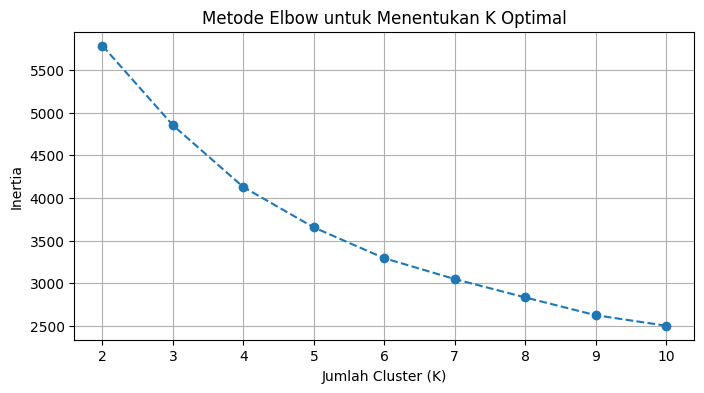

In [7]:
# Mencari jumlah cluster (K) optimal dengan metode Elbow
inertia = []
K_range = range(2, 11) # Mulai dari 2 cluster
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Metode Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan K Optimal')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

Eksekusi K-Means & Evaluasi (Silhouette Score)

In [8]:
# Menggunakan K=3 (Misalnya dari hasil pengamatan Elbow)
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

# Memasukkan hasil prediksi cluster ke dalam dataframe
df_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Evaluasi menggunakan Silhouette Score
sil_score = silhouette_score(X_scaled, df_clean['Cluster'])
print(f"Silhouette Score untuk K={k_optimal}: {sil_score:.3f}")

Silhouette Score untuk K=3: 0.271


Visualisasi Hasil Clustering 2D

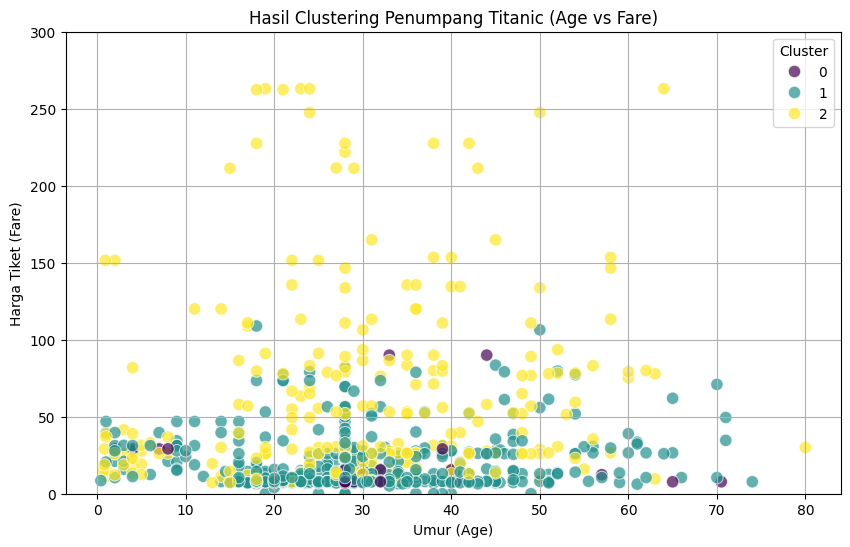

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_clean['Age'],
    y=df_clean['Fare'],
    hue=df_clean['Cluster'],
    palette='viridis',
    s=80,
    alpha=0.7
)
plt.title('Hasil Clustering Penumpang Titanic (Age vs Fare)')
plt.xlabel('Umur (Age)')
plt.ylabel('Harga Tiket (Fare)')
# Membatasi sumbu y jika ada outlier harga tiket yang terlalu tinggi agar grafik lebih jelas
plt.ylim(0, 300)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()